
##  Loading the Dataset 

### Enviroment SetUP

In [ ]:
%pip install pandas numpy matplotlib  

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.3 MB 2.1 MB/s eta 0:00:04
   ------ --------------------------------- 1.3/8.3 MB 3.1 MB/s eta 0:00:03
   ------ --------------------------------- 1.3/8.3 MB 3.1 MB/s eta 0:00:03
   ------- -------------------------------- 1.6/8.3 MB 2.0 MB/s eta 0:00:04
   ----------- ---------------------------- 2.4/8.3 MB 2.5 MB/s eta 0:00:03
   ------------------ --------------------- 3.9/8.3 MB 3.1 MB/s eta 0:00:02
   ---------------------- ----------------- 4.7/8.3 MB 3.5 MB/s eta 0:00:02
   -------------------------- ------------- 5.5/8.3 MB 3.5 MB/s eta 0:00:01
   ---------------------------------- ----- 7.1/8.3 MB 3.8 MB/s eta 0:00:01
   ------------------------------------ --- 7.6/8.3 MB 3.7 MB/s eta 0:00:01
   ------------------------------


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
### Import required libraries

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Loading the Dataset

In [10]:

df = pd.read_csv("data/heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [11]:
df["target"].value_counts()

target
1    526
0    499
Name: count, dtype: int64

In [12]:
### Binarize the target column: 1 = disease present, 0 = no disease

df["target"] = df["target"].apply(
    lambda v: 1 if v in (1, "yes", "Yes", "True", "present") else 0
).astype(int)

print(df["target"].value_counts())
print("dtype:", df["target"].dtype)

target
1    526
0    499
Name: count, dtype: int64
dtype: int64


In [16]:
df.describe()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [17]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

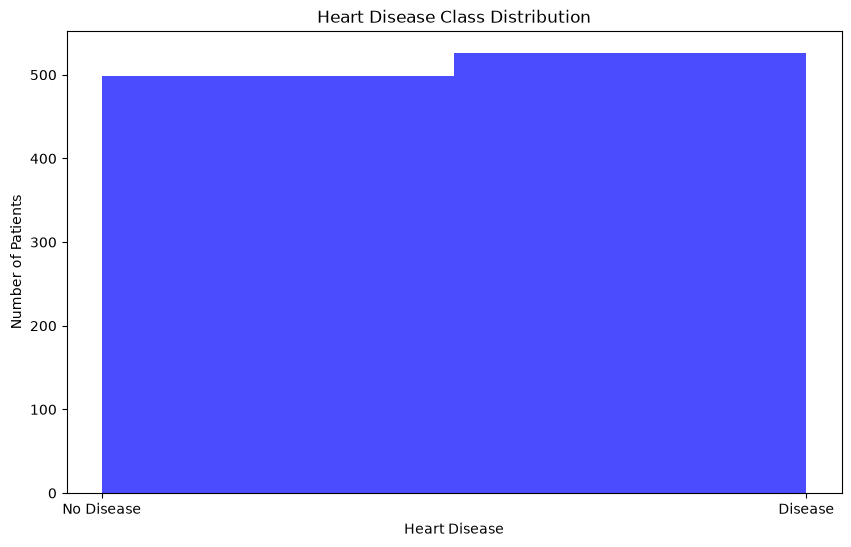

In [20]:
plt.figure(figsize=(10, 6))
plt.hist(df["target"], bins=2, color="blue", alpha=0.7)
plt.title("Heart Disease Class Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Number of Patients")
plt.xticks([0, 1], ["No Disease", "Disease"])
plt.show()

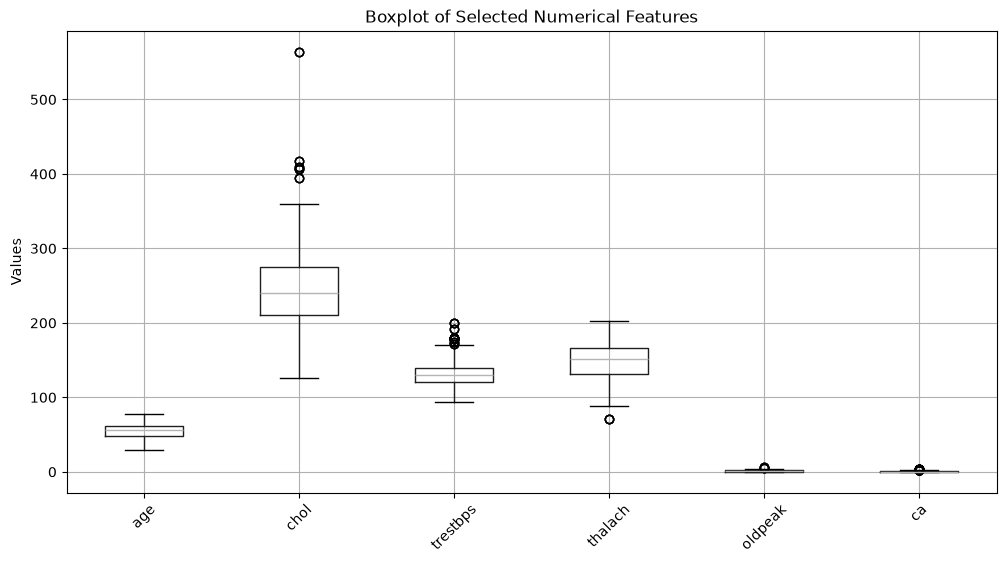

In [21]:
features = ["age", "chol", "trestbps", "thalach", "oldpeak", "ca"]

plt.figure(figsize=(12, 6))

df[features].boxplot()

plt.title("Boxplot of Selected Numerical Features")
plt.ylabel("Values")
plt.xticks(rotation=45)

plt.show()

In [33]:
features = [
    "age",
    "chol",
    "trestbps",
    "thalach",
    "oldpeak",
    "ca"
]

X = df[features]
y = df["target"]

In [35]:
np.random.seed(42)

indices_0 = df[df["target"] == 0].index.to_numpy().copy()
indices_1 = df[df["target"] == 1].index.to_numpy().copy()

np.random.shuffle(indices_0)
np.random.shuffle(indices_1)

split_0 = int(len(indices_0) * 0.70)
split_1 = int(len(indices_1) * 0.70)

train_indices = np.concatenate([
    indices_0[:split_0],
    indices_1[:split_1]
])

test_indices = np.concatenate([
    indices_0[split_0:],
    indices_1[split_1:]
])

X_train = df.loc[train_indices, features]
X_test = df.loc[test_indices, features]

y_train = df.loc[train_indices, "target"]
y_test = df.loc[test_indices, "target"]

In [36]:
print("Training:", X_train.shape)
print("Test:", X_test.shape)

print("\nTraining distribution:")
print(y_train.value_counts())

print("\nTest distribution:")
print(y_test.value_counts())

Training: (717, 6)
Test: (308, 6)

Training distribution:
target
1    368
0    349
Name: count, dtype: int64

Test distribution:
target
1    158
0    150
Name: count, dtype: int64


## Logistic Regression